In [120]:
#%%
import math
import numpy as np
import inspect
import importlib

import scipy.interpolate

import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
from matplotlib import patches as mpatches

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 16

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.offline import plot
pio.renderers.default = "svg"

import sys
import os
parent_directory = os.path.dirname(os.getcwd())
sys.path.append(parent_directory)
#sys.path.append(os.path.dirname(parent_directory))
#sys.path.append(os.path.dirname(os.path.dirname(parent_directory)))

from IoT_node_models.Energy_model                        import *
from IoT_node_models.Energy_model.Wireless_communication import *
from IoT_node_models.Hardware_Modules                    import *
from IoT_node_models.Analysis                            import *

path_to_save_svg = "Saved_Data"



In [121]:
dictColor = {"DeepBlue"     :"#095256",
             "LightBlue"    :"#01a7c2",
             "UnitedBlue"   :"#6290c8",
             "CerulBlue"    :"#6096ba",
             "Green"        :"#44af69",
             "LightRed"     :"#f8333c",
             "DeepRed"      :"#a22c29",
             "Orange"       :"#fcab10",
             "Sandy"        :"#fc9e4F",
             "Olivine"      :"#9ab87a",
             "CarolinaBlue" :"#009DDC"}
listColor = list(dictColor.values())

In [122]:
###############################################
# Based on  Apollo 3 datasheet
###############################################
MCU_Clock_freq = 20 #MHz

MCU_module = Node_module(name="Apollo3",
                            v      =1.8,
                            i_sleep=0.05)

#MCU_state_active  = Module_state("Active"      ,i = 0.045*    MCU_Clock_freq,duration = None)
MCU_state_active  = Module_state("Active"      ,i = 0.018*    MCU_Clock_freq,duration = None)
MCU_state_fftHW   = Module_state("512-ptFFT HW",i = (5.5/128)*MCU_Clock_freq,duration = None)

MCU_module.add_state(MCU_state_active)
MCU_module.add_state(MCU_state_fftHW)

In [123]:
###############################################
# Based on  STM32 L4 datasheet, coremark ex
###############################################
MCU_Clock_freq = 2 #MHz

MCU_module = Node_module(name="STM32F4",
                            v      =1.8,
                            i_sleep=6.9e-3)

MCU_state_active  = Module_state("Active"      ,i = 0.145*    MCU_Clock_freq,duration = None)
MCU_state_fftHW   = Module_state("512-ptFFT HW",i = (5.5/128)*MCU_Clock_freq,duration = None)

MCU_module.add_state(MCU_state_active)
MCU_module.add_state(MCU_state_fftHW)

In [124]:
###############################################
# Based on  STM32 L4 datasheet
###############################################
fs = 10e3
DMA_Clock_freq = fs/1e6 #MHz

DMA_module = Node_module(name="DMA",
                            v      =1.8,
                            i_sleep=0.00)

DMA_state_active  = Module_state("Active",i = (1/1000)*(1.4)*DMA_Clock_freq,duration = None)

DMA_module.add_state(DMA_state_active)

In [125]:
Micro_module = Node_module(name="MicroIC",
                            v      =1.8,
                            i_sleep=0.000)

#Micro_state_active  = Module_state("Active",i = 0.2,duration = None) 
Micro_state_active  = Module_state("Active",i = 0.016,duration = None) #ICS-40310 

Micro_module.add_state(Micro_state_active)

In [126]:
TRX_module = Node_module(name="LoRa radio",
                            v=1.8,
                            i_sleep=0)#6e-3)
TRX_state_TX = Module_state("TX",i = 0, duration = None)#52,duration = None)
TRX_state_RX = Module_state("RX",i = 0, duration = None)#22,duration = None)
TRX_module.add_state(TRX_state_TX)
TRX_module.add_state(TRX_state_RX)

In [127]:

module_List = [MCU_module,DMA_module,Micro_module,TRX_module]

In [128]:
fs = 10e3


Samples_p_melvec = 512
N_melvec         = 10

MFCC_aquisition_duration         = (N_melvec*Samples_p_melvec/fs)
Audio_classification_p_day       = 0.95*np.floor(24*60*60 / MFCC_aquisition_duration)

print("Acquisition duration  : %.2fms "%((MFCC_aquisition_duration ) *1e3))
print("Inference p day       : %d "%(int(Audio_classification_p_day)))
print()

# From Thomas Antoine Master thesis
Cycles_p_inference      =    (N_melvec*25033 / 0.62) * 0.25 / 0.7482
Cycles_p_mfcc_wO_FFT    =    N_melvec*((25033 / 0.62)-25033)

FFTSW_Cycles            =    N_melvec*25033
Radix = 2**4
FFTHW_Cycles            =    N_melvec*(2*(Samples_p_melvec*np.ceil(np.log2(Samples_p_melvec)/np.log2(Radix))))/2

print("Cycle for inference   : %d"%(int(Cycles_p_inference)))
print("Cycle for MFCC wO FFT : %d"%(int(Cycles_p_mfcc_wO_FFT)))
print("Cycle for FFTs :   SW : %d  "%(int(FFTSW_Cycles)))
print("                   HW : %d  "%(int(FFTHW_Cycles)))
print()

Inference_duration               = Cycles_p_inference/(MCU_Clock_freq*1e6)
MFCC_calculation_wO_FFT_duration = Cycles_p_mfcc_wO_FFT/(MCU_Clock_freq*1e6)
MFCC_FFT_SW_duration             = FFTSW_Cycles/(MCU_Clock_freq*1e6)
MFCC_FFT_HW_duration             = FFTHW_Cycles/(MCU_Clock_freq*1e6)

print("Inference duration     : %.2fms "%((Inference_duration ) *1e3))
print("MFCC wO FFT duration   : %.2fms "%((MFCC_calculation_wO_FFT_duration ) *1e3))
print("Duration for FFTs : SW : %.2fms  "%(MFCC_FFT_SW_duration*1e3))
print("                    HW : %.2fms  "%(MFCC_FFT_HW_duration*1e3))

print("")
print("Computation time per inference: SW FFT: %.2fms  "%((MFCC_FFT_SW_duration+Inference_duration+MFCC_calculation_wO_FFT_duration)*1e3))
print("Computation time per inference: HW FFT: %.2fms  "%((MFCC_FFT_HW_duration+Inference_duration+MFCC_calculation_wO_FFT_duration)*1e3))


print("")
print("Percentage of computing time per day: SW FFT: %.2f%%  "%(100*(MFCC_FFT_SW_duration+Inference_duration+MFCC_calculation_wO_FFT_duration)*Audio_classification_p_day/(24*60*60)))
print("Percentage of computing time per day: HW FFT: %.2f%%  "%(100*(MFCC_FFT_HW_duration+Inference_duration+MFCC_calculation_wO_FFT_duration)*Audio_classification_p_day/(24*60*60)))



Acquisition duration  : 512.00ms 
Inference p day       : 160312 

Cycle for inference   : 134909
Cycle for MFCC wO FFT : 153428
Cycle for FFTs :   SW : 250330  
                   HW : 15360  

Inference duration     : 67.45ms 
MFCC wO FFT duration   : 76.71ms 
Duration for FFTs : SW : 125.16ms  
                    HW : 7.68ms  

Computation time per inference: SW FFT: 269.33ms  
Computation time per inference: HW FFT: 151.85ms  

Percentage of computing time per day: SW FFT: 49.97%  
Percentage of computing time per day: HW FFT: 28.18%  


In [129]:

Audio_classification_w_SWFFT =  Node_task(  name = "Audio class. w. SW FFT", 
                        node_modules= module_List, 
                        subtasks   = [  Node_subtask(name='Acquisition',module=Micro_module,
                                        moduleState = Micro_state_active, stateDuration=MFCC_aquisition_duration),
                                        Node_subtask(name='DMA transfer',module=DMA_module ,
                                        moduleState = DMA_state_active     , stateDuration=(1/10)*MFCC_aquisition_duration),
                                        Node_subtask(name='MFCC w/o FFT'  ,module=MCU_module ,
                                        moduleState = MCU_state_active  , stateDuration=MFCC_calculation_wO_FFT_duration),
                                        Node_subtask(name='Inference'  ,module=MCU_module ,
                                        moduleState = MCU_state_active  , stateDuration=Inference_duration),
                                        Node_subtask(name='SW FFT'  ,module=MCU_module ,
                                        moduleState = MCU_state_active  , stateDuration=MFCC_FFT_SW_duration)
                        ],
                        taskDuration = MFCC_aquisition_duration, 
                        )

Audio_classification_w_HWFFT =  Node_task(  name = "Audio class. w. HW FFT", 
                        node_modules= module_List, 
                        subtasks   = [  Node_subtask(name='Acquisition',module=Micro_module,
                                        moduleState = Micro_state_active, stateDuration=MFCC_aquisition_duration),
                                        Node_subtask(name='DMA transfer',module=DMA_module ,
                                        moduleState = DMA_state_active     , stateDuration=(1/10)*MFCC_aquisition_duration),
                                        Node_subtask(name='MFCC w/o FFT'  ,module=MCU_module ,
                                        moduleState = MCU_state_active  , stateDuration=MFCC_calculation_wO_FFT_duration),
                                        Node_subtask(name='Inference'  ,module=MCU_module ,
                                        moduleState = MCU_state_active  , stateDuration=Inference_duration),
                                        Node_subtask(name='HW FFT'  ,module=MCU_module ,
                                        moduleState = MCU_state_fftHW  , stateDuration=MFCC_FFT_HW_duration)
                        ],
                        taskDuration = MFCC_aquisition_duration, 
                        )


In [130]:
                    # 512-pt FFT is 46 % of MFCC : 
print("Cycle for total  : w. SW FFT %d  \t--- vs --- %d      \tw. HW FFT"%(int(Cycles_p_inference+Cycles_p_mfcc_wO_FFT+FFTSW_Cycles),int(Cycles_p_inference+Cycles_p_mfcc_wO_FFT+FFTHW_Cycles)))
print("Total Duration   : w. SW FFT %.2fms \t--- vs --- %.2fms  \tw. HW FFT"%(1e3*(Inference_duration+MFCC_calculation_wO_FFT_duration+MFCC_FFT_SW_duration), 1e3*(Inference_duration+MFCC_calculation_wO_FFT_duration+MFCC_FFT_HW_duration)))


print("Acquisition duration     : %.2fms "%((MFCC_aquisition_duration ) *1e3))

print("MFCC acquisition time : %.2fms --- vs --- %.2fms : Calc. time (Full SW)"%(MFCC_aquisition_duration*1e3, (Inference_duration+MFCC_calculation_wO_FFT_duration+MFCC_FFT_SW_duration) *1e3))
if MFCC_aquisition_duration<(Inference_duration+MFCC_calculation_wO_FFT_duration+MFCC_FFT_SW_duration):
    raise Exception("Melvec acquisition duration is shorter than processing duration!")

Cycle for total  : w. SW FFT 538667  	--- vs --- 303697      	w. HW FFT
Total Duration   : w. SW FFT 269.33ms 	--- vs --- 151.85ms  	w. HW FFT
Acquisition duration     : 512.00ms 
MFCC acquisition time : 512.00ms --- vs --- 269.33ms : Calc. time (Full SW)


In [131]:
node_LDO = LDO      (name = "Node LDO",   v_out = 1.8, i_q = 1e-3, v_in = 3.3, module_list = module_List)
node_Batt= Battery  (name = "Node Batt.", v = 3.3, capacity_mAh = 1800, i = 0, selfdischarge_p_year = 0)

node_lora = LoRa_Node(name= "IoT Node", module_list= module_List, PMU_composition =[node_LDO], Battery = node_Batt, radio_module = TRX_module)

node= LoRa_Node_profile("Node_profile", node_lora,  RX_state=TRX_state_RX,TX_state=TRX_state_TX,
                    P_TX= PTX_PABOOST_configured, I_TX=I_PABoost_1V8 ) 
              


In [132]:
this_task_tx = node.create_task_tx(name="TX-0", Ptx = 17,SF=7 ,Coding=1,Header=True,DE = 1,BW = 125e3, Payload = 50, TX_rate=24*1)
this_task_rx = node.create_task_rx(name="RX-0", RX_rate=2, RX_duration=0.250 )

In [133]:
def PL_model(d):
    return path_loss(d=d,f = 868e6, n=3)
    #return path_loss_PLd0(d=d, PLd0=94.40,d0=1, n=2.03)

this_task_tx.set_Path_loss_model(PL_model)
this_task_tx.set_distance( d= 1000)

node.change_task_rate(this_task_tx,24*6)
node.change_task_rate(this_task_rx,24*6)

In [134]:
node.add_task(Audio_classification_w_SWFFT ,task_rate=1)
node.add_task(Audio_classification_w_HWFFT ,task_rate=1)

In [135]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [136]:
node.change_task_rate(Audio_classification_w_SWFFT      ,Audio_classification_p_day)
node.change_task_rate(Audio_classification_w_HWFFT      ,0)

-------------------------------------------------
            Tasks summary                        
-------------------------------------------------
Task name            : Sleep          TX-0           RX-0           Audio class. w. SW FFTAudio class. w. HW FFT
Times/day    [1/d]   : 1              144            144            160312.5       0              
Tot. durat.  [s]     : 4265.5311      18.4689        36.0000        82080.0000     0.0000         
Tot. en./d   [mJ]    : 52.9779        1263.4997      0.4471         25385.9840     0.0000         
Node en./d   [mJ]    : 26702.9087      
Average pow. [mW]    : 0.3091          
-------------------------------------------------
-----------------------------------------------------------------
                        Module summary                           
-----------------------------------------------------------------
Module       State        Active [s]   Energy [mJ]  Av. Cur.[uA]  
STM32F4                   43177.5964   23075.

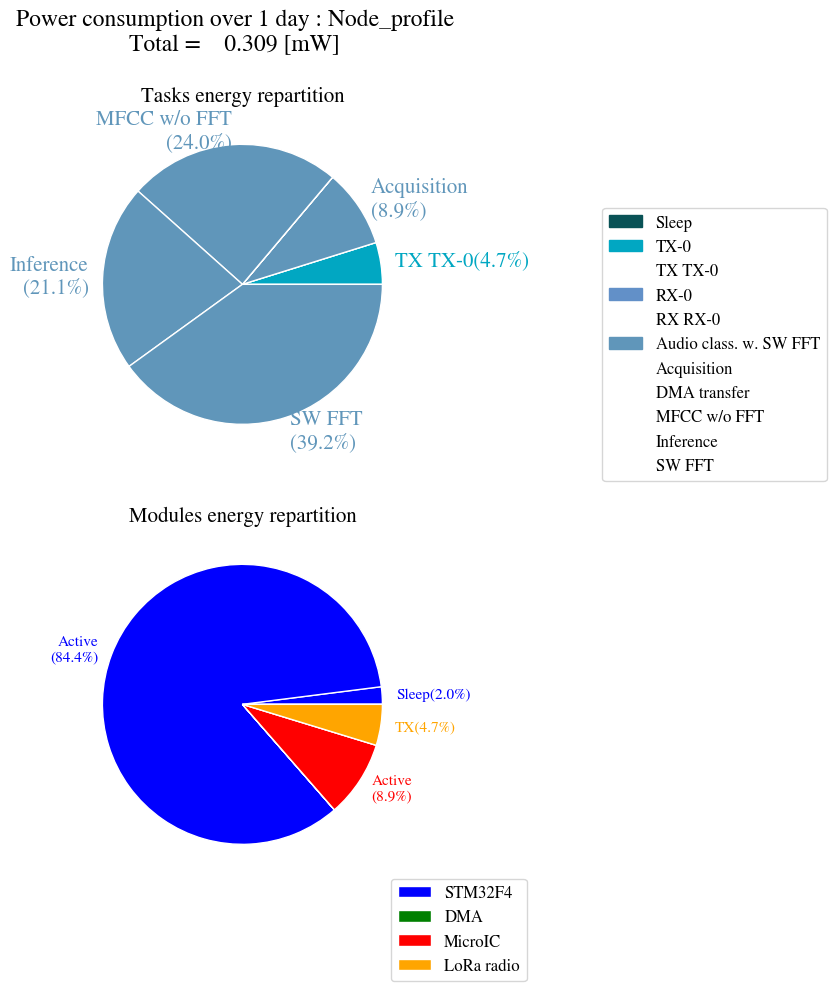

In [137]:
try:
    node.compute()
except Exception as e:
    print("An error occurred during the computation of the node profile:")
    print(e)
node.print_Tasks()
node.print_Modules()
node.plot_Power(plotSubtask=True)

In [139]:
node.change_task_rate(Audio_classification_w_HWFFT      ,Audio_classification_p_day)
node.change_task_rate(Audio_classification_w_SWFFT      ,0)

-------------------------------------------------
            Tasks summary                        
-------------------------------------------------
Task name            : Sleep          TX-0           RX-0           Audio class. w. SW FFTAudio class. w. HW FFT
Times/day    [1/d]   : 1              144            144            0              160312.5       
Tot. durat.  [s]     : 4265.5311      18.4689        36.0000        0.0000         82080.0000     
Tot. en./d   [mJ]    : 52.9779        1263.4997      0.4471         0.0000         15336.1591     
Node en./d   [mJ]    : 16653.0838      
Average pow. [mW]    : 0.1927          
-------------------------------------------------
-----------------------------------------------------------------
                        Module summary                           
-----------------------------------------------------------------
Module       State        Active [s]   Energy [mJ]  Av. Cur.[uA]  
STM32F4                   24343.2824   13025.

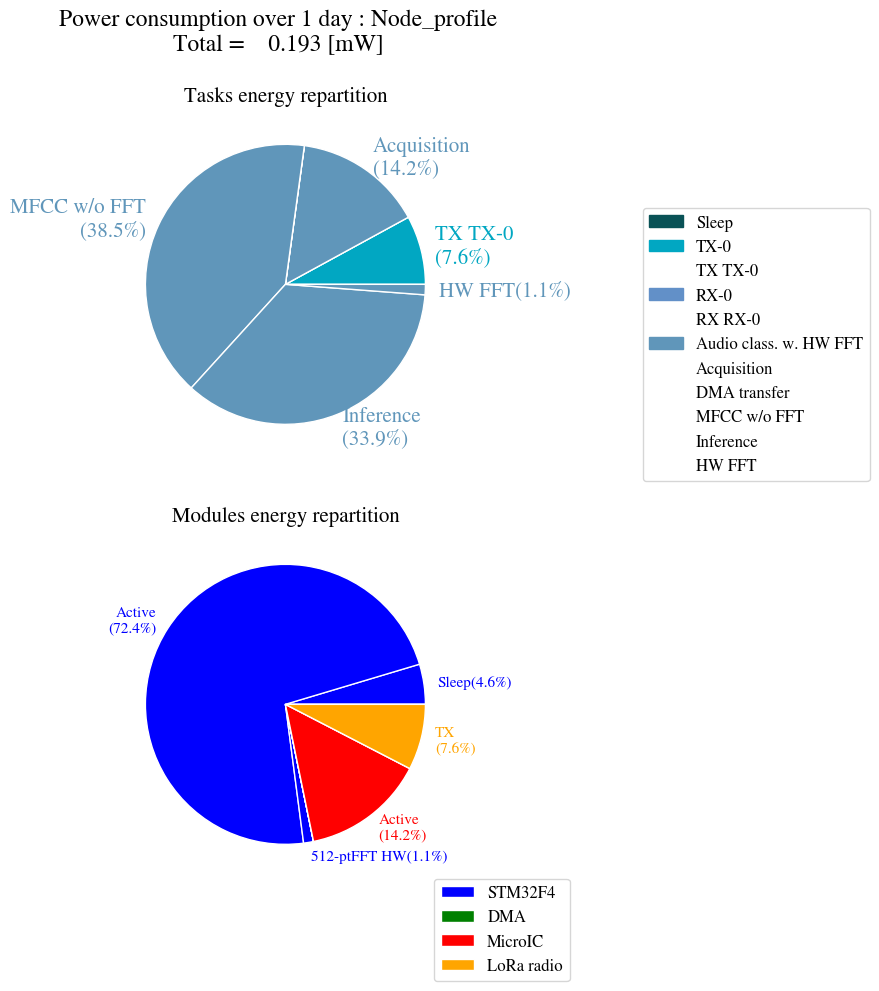

In [140]:
try:
    node.compute()
except Exception as e:
    print("An error occurred during the computation of the node profile:")
    print(e)
node.print_Tasks()
node.print_Modules()
node.plot_Power(plotSubtask=True)

In [ ]:
show = 0

AA_series = 3
AA_footprint = 0.165
AA_cost      = 0.25 
Batt_footprint = AA_series*AA_footprint
Batt_cost      = AA_series*AA_cost

placementNnodes   = 100
decomNnodes       = 100
replacementNnodes = 10

transport_f =   transport_footprint(km_one_way = 10, 
                                    type ="Unit", 
                                    weight_g = 500,  
                                    footprint_p_tkm = 0.545,
                                    unit_factor = 1,
                                    footprint_p_km = 0.350)

transport_c =   transport_cost( worker = 1, salary_p_hour = 20, work_hour =0.3, km_p_h = 50,km_one_way = 10, 
                                type ="Unit", 
                                weight_g = 500, cost_p_tkm =  0.2/1e3,
                                unit_factor = 1,cost_p_km = 0.2)
    

node_footprint = Node_BoM(  casing            =[0.709,    0.3932, 1.3259], #709
                            connectivtiy      =[0.517,    0.2262, 0.5817],
                            eol               =[0.0812,   0.0388, 0.1201],
                            memory            =[0,        0,      0     ],
                            others            =[0.0938,   0.0546, 0.1394],
                            pcb               =[1.17,     0.9403, 1.5696], #1.17
                            power_supply      =[0.132,    0.0446, 0.1751],
                            processing        =[0.366,    0.3665, 0.4537],
                            sensing           =[0.0539,   0.0539, 0.5561],
                            ui                =[0.0306,   0.0017, 0.1155],
                            transport         =[transport_f*show,transport_f*show,transport_f*show],
                            battery           =[Batt_footprint  ,Batt_footprint,Batt_footprint],
                            placement         =[transport_f,transport_f,transport_f],
                            replacement       =[transport_f,transport_f,transport_f],
                            decom             =[transport_f,transport_f,transport_f], 
                            placementNnodes   = placementNnodes,
                            decomNnodes       = decomNnodes,
                            replacementNnodes = replacementNnodes)


node_Cost   = Node_BoM(     casing            =[10    ,    0 , 0], #ABS , IP rated
                            connectivtiy      =[5.3   ,    0 , 0], #SX1276 : 5.3
                            eol               =[0     ,    0 , 0],
                            memory            =[0     ,    0 , 0],
                            others            =[1.42  ,    0 , 0], #MLCC : 0.05*15 + XTAL32MHz: 0.5 + R: 0.002*15 + D : 0.07*2  
                            pcb               =[1.17  ,    0 , 0], #PCB 60cm2 : 1.75 
                            power_supply      =[0.228 ,    0 , 0], #XC6206 : 0.228 + Diode and Transistor?
                            processing        =[3.65  ,    0 , 0], #Apollo3: 3.65
                            sensing           =[6.94  ,    0 , 0], #BME680 : 6.94
                            ui                =[0.54  ,    0 , 0], #Push button : 0.17*2 + LED SMD : 0.2*1
                            transport         =[transport_c,0 , 0],
                            battery           =[Batt_cost  ,0 , 0],
                            placement         =[transport_c,0 , 0],
                            replacement       =[transport_c,0 , 0],
                            decom             =[transport_c,0 , 0],
                            placementNnodes   = 100,
                            decomNnodes       = 100,
                            replacementNnodes = 10)
